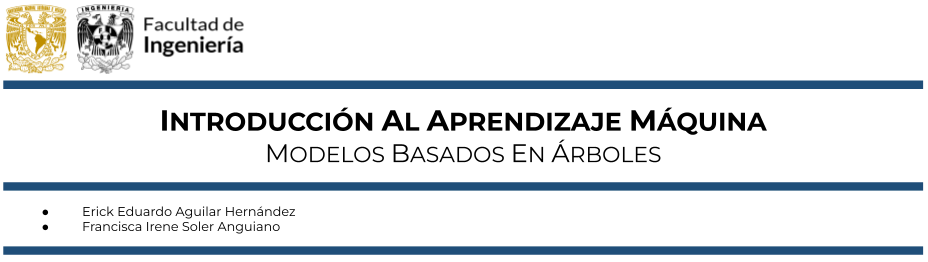

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Capítulo**

Capítulo 4. Sobreajuste y regularización

**Licencia**

MIT License

___
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___

### Notebook 4.3.4 — Implementación: poda por costo-complejidad en árboles de regresión
___

### Preparación del entorno de trabajo

Se importan las bibliotecas necesarias para trabajar con datos, ajustar árboles de regresión, generar particiones de validación cruzada y visualizar los árboles resultantes. 
También se cargan funciones de métricas y `plot_tree`, ya que la poda por costo-complejidad requiere evaluar el desempeño de múltiples subárboles y comparar su estructura final.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.tree import plot_tree
from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import explained_variance_score as expv
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')


### Función auxiliar para métricas de regresión

Aunque la optimización de este notebook se hará con RMSE, se conserva una función general para resumir métricas de regresión cuando sea necesario comparar predicciones observadas y estimadas. 
Estas métricas permiten conectar la poda con el análisis de desempeño fuera de muestra discutido en el capítulo anterior.


In [2]:
def get_metrics(df, target_col, prediction_col, fold='Training'):
  metrics_dict = {'fold':fold}
  metrics_dict.update({'R2':r2(df[target_col],df[prediction_col])})
  metrics_dict.update({'MAE':mae(df[target_col],df[prediction_col])})
  metrics_dict.update({'MSE':mse(df[target_col],df[prediction_col])})
  metrics_dict.update({'RMSE':np.sqrt(mse(df[target_col],df[prediction_col]))})
  metrics_dict.update({'ExpVar':expv(df[target_col],df[prediction_col])})
  return metrics_dict


### Carga del conjunto Auto MPG

Se carga el conjunto **Auto MPG**, empleado a lo largo del libro para estudiar árboles de regresión. 
La variable respuesta es `mpg`, mientras que las variables predictoras describen características técnicas del vehículo. 
El objetivo será controlar la complejidad del árbol que predice el rendimiento de combustible a partir de estas covariables.


In [3]:
data_paths = [Path("datos") / "mpg.csv", Path("..") / "datos" / "mpg.csv"]
data_path = next(path for path in data_paths if path.exists())
mpg_df = pd.read_csv(data_path).dropna()

features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

X = mpg_df[features]
y = mpg_df["mpg"]

display(mpg_df)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


### RMSE como función objetivo

La poda por costo-complejidad requiere una métrica para comparar el desempeño de los árboles candidatos. 
En esta implementación se utiliza el RMSE, que mide la magnitud promedio del error en las mismas unidades de la variable respuesta. 
Esta función será la cantidad a minimizar durante la validación cruzada de los distintos valores de `ccp_alpha`.


In [4]:
# definimos metrica como funcion objeitvo 
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

### Función de poda por costo-complejidad con validación cruzada

La función construye primero la ruta de poda del árbol mediante `cost_complexity_pruning_path`, que entrega una secuencia de valores candidatos de `ccp_alpha`. 
Para cada valor de alpha se ajusta un árbol en varias particiones `K-fold` y se calcula el error promedio de validación junto con su desviación estándar y error estándar. 
Después se seleccionan dos candidatos: `alpha_min`, que minimiza el error promedio, y `alpha_1se`, que aplica la regla de una desviación estándar para preferir el árbol más simple cuyo error no sea significativamente peor que el mínimo.


In [5]:
# ------------------------------------------------------------
#    Validación cruzada para un conjunto de alphas (ccp_alpha)
#    Optimiza costo-complejidad seleccionando el alpha con menor error medio.
#    (Por defecto optimiza RMSE; puedes cambiar metric_fn)
# ------------------------------------------------------------



def cv_cost_complexity_pruning(
    X, y,
    base_params=None,
    n_splits=5,
    random_state=42,
    metric_fn=rmse,            # métrica a minimizar
    use_unique_alphas=True,
    max_alphas=50              # para acotar (opcional) si hay demasiados alphas
):
    if base_params is None:
        base_params = {}

    # Árbol base para obtener la ruta de poda (ccp_alphas)
    base_tree = DecisionTreeRegressor(random_state=random_state, **base_params)
    path = base_tree.cost_complexity_pruning_path(X, y)
    alphas = path.ccp_alphas

    if use_unique_alphas:
        alphas = np.unique(alphas)

    # A veces el último alpha poda todo (árbol raíz). Se puede conservar o quitar.
    # Aquí lo conservamos, pero si quieres puedes hacer: alphas = alphas[:-1]
    if max_alphas is not None and len(alphas) > max_alphas:
        # Submuestreo uniforme de alphas para ahorrar cómputo
        idx = np.linspace(0, len(alphas) - 1, max_alphas).astype(int)
        alphas = alphas[idx]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []
    for a in alphas:
        fold_scores = []
        for tr_idx, va_idx in kf.split(X):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            model = DecisionTreeRegressor(
                random_state=random_state,
                ccp_alpha=float(a),
                **base_params
            )
            model.fit(X_tr, y_tr)
            y_hat = model.predict(X_va)

            fold_scores.append(metric_fn(y_va, y_hat))

        fold_scores = np.array(fold_scores, dtype=float)
        rows.append({
            "ccp_alpha": float(a),
            "cv_mean": fold_scores.mean(),
            "cv_std": fold_scores.std(ddof=1),
            "cv_se": fold_scores.std(ddof=1) / np.sqrt(n_splits)
        })

    cv_df = pd.DataFrame(rows).sort_values("ccp_alpha").reset_index(drop=True)

    # Alpha que minimiza el error medio
    best_idx = cv_df["cv_mean"].idxmin()
    alpha_min = cv_df.loc[best_idx, "ccp_alpha"]
    min_mean = cv_df.loc[best_idx, "cv_mean"]
    min_se   = cv_df.loc[best_idx, "cv_se"]

    # Regla 1-SE: elegir el árbol más simple (alpha más grande)
    # cuyo error esté dentro de (min_mean + min_se)
    threshold = min_mean + min_se
    eligible = cv_df[cv_df["cv_mean"] <= threshold]
    alpha_1se = eligible["ccp_alpha"].max()

    summary = {
        "alpha_min": float(alpha_min),
        "alpha_1se": float(alpha_1se),
        "min_cv_mean": float(min_mean),
        "min_cv_se": float(min_se),
        "threshold_1se": float(threshold),
        "n_alphas_evaluated": int(len(cv_df))
    }
    summary_df = pd.DataFrame([summary.keys(),summary.values()]).transpose()

    return cv_df, summary_df, summary

### Evaluación de la ruta de poda en Auto MPG

Se fija una configuración base para crecer un árbol suficientemente flexible antes de aplicar la poda. 
Luego se evalúan hasta 50 valores de `ccp_alpha` mediante validación cruzada de 5 folds, usando RMSE como métrica de error. 
El resumen muestra el alpha con menor error medio y el alpha elegido por la regla 1-SE, junto con el umbral que define qué modelos se consideran estadísticamente comparables al óptimo.


In [6]:
base_params = {
    "max_depth": 10,
    "min_samples_leaf": 5
}

cv_df, summary_df, summary = cv_cost_complexity_pruning(
    X=X,
    y=y,
    base_params=base_params,
    n_splits=5,
    random_state=42,
    metric_fn=rmse, # minimiza RMSE
    max_alphas=50
)

print("Resumen selección de alpha:")
display(summary_df.head(10))
display(cv_df.head(10))

Resumen selección de alpha:


,0,1
0,alpha_min,0.002234
1,alpha_1se,0.267284
2,min_cv_mean,3.277424
3,min_cv_se,0.159123
4,threshold_1se,3.436547
5,n_alphas_evaluated,50


,ccp_alpha,cv_mean,cv_std,cv_se
0,0.000000,3.277472,0.355797,0.159117
1,0.000309,3.277472,0.355797,0.159117
2,0.001235,3.277472,0.355797,0.159117
3,0.002234,3.277424,0.355810,0.159123
4,0.003401,3.277841,0.358574,0.160359
5,0.004933,3.278346,0.359083,0.160587
6,0.006378,3.278215,0.359224,0.160650
7,0.006614,3.278215,0.359224,0.160650
8,0.009470,3.283630,0.368539,0.164816
9,0.010292,3.280359,0.370111,0.165519


### Curva de optimización por costo-complejidad

La curva muestra cómo cambia el RMSE promedio de validación cruzada al variar `ccp_alpha`. 
La banda sombreada representa una desviación estándar del error estimado alrededor del promedio, mientras que las líneas verticales identifican `alpha_min` y `alpha_1se`. 
El eje horizontal se presenta en escala logarítmica porque los valores de alpha suelen crecer de manera irregular o casi exponencial a lo largo de la ruta de poda.


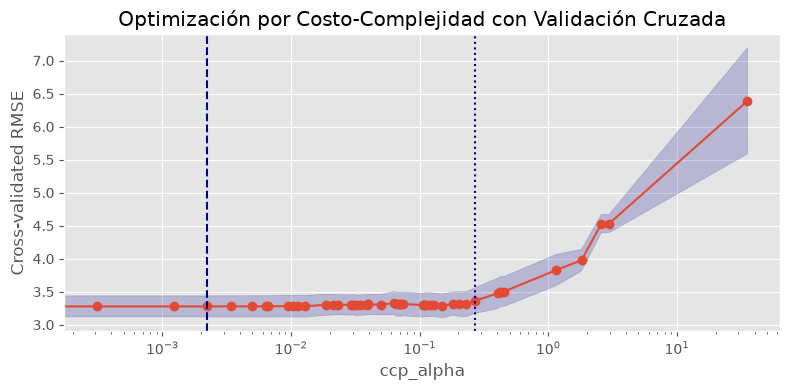

In [7]:
plt.figure(figsize=(8,4))

# Curva principal
plt.plot(cv_df["ccp_alpha"],
         cv_df["cv_mean"],
         marker="o")

# Banda de ± 1 SE
plt.fill_between(
    cv_df["ccp_alpha"],
    cv_df["cv_mean"] - cv_df["cv_se"],
    cv_df["cv_mean"] + cv_df["cv_se"],
    color='darkblue',
    alpha=0.2
)

# Líneas verticales para alpha_min y alpha_1se
plt.axvline(summary["alpha_min"], linestyle="--", color='darkblue')
plt.axvline(summary["alpha_1se"], linestyle=":", color='darkblue')

plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated RMSE")
plt.title("Optimización por Costo-Complejidad con Validación Cruzada")
plt.xscale("log")  # recomendable porque los alphas suelen crecer exponencialmente
plt.tight_layout()
plt.show()

### Árbol seleccionado por mínimo error promedio

Con `alpha_min` se ajusta el árbol que obtiene el menor RMSE promedio en validación cruzada. 
Este modelo representa el criterio de selección basado estrictamente en minimizar el error estimado. 
Después de entrenarlo con todos los datos disponibles, se reportan su número de hojas y profundidad para visualizar la complejidad estructural asociada al alpha óptimo por error mínimo.


Hojas (alpha_min): 61
Profundidad: 9


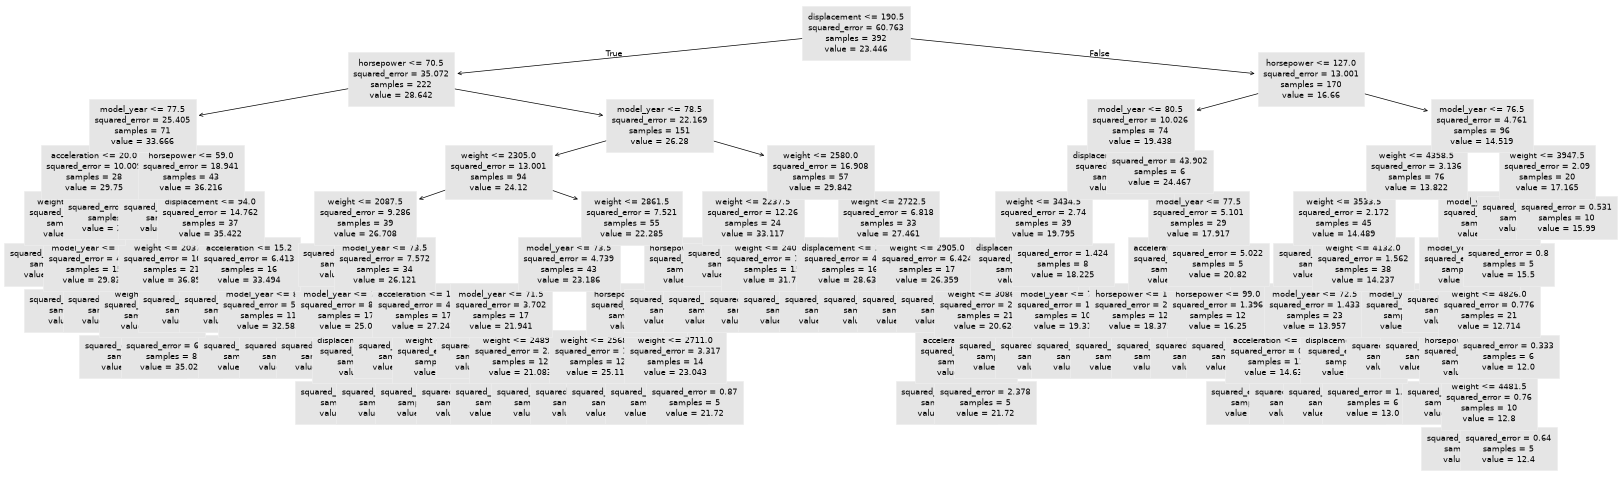

In [8]:
model_min = DecisionTreeRegressor(random_state=42,
                                  ccp_alpha=summary["alpha_min"],
                                  **base_params).fit(X, y)

print("Hojas (alpha_min):", model_min.get_n_leaves())
print("Profundidad:", model_min.get_depth())
plt.figure(figsize=(20,6))
ars = plot_tree(model_min, feature_names=features, fontsize=6)

### Árbol seleccionado por la regla 1-SE

La regla 1-SE elige el árbol más simple cuyo error de validación cruzada permanece dentro de una desviación estándar del mínimo observado. 
Este criterio introduce parsimonia: acepta una pérdida predictiva pequeña, estadísticamente indistinguible del óptimo, a cambio de una estructura menos compleja y potencialmente más estable. 
El árbol resultante se compara con el modelo de `alpha_min` mediante su número de hojas, profundidad y representación gráfica.


Hojas (alpha_1se): 12
Profundidad: 5


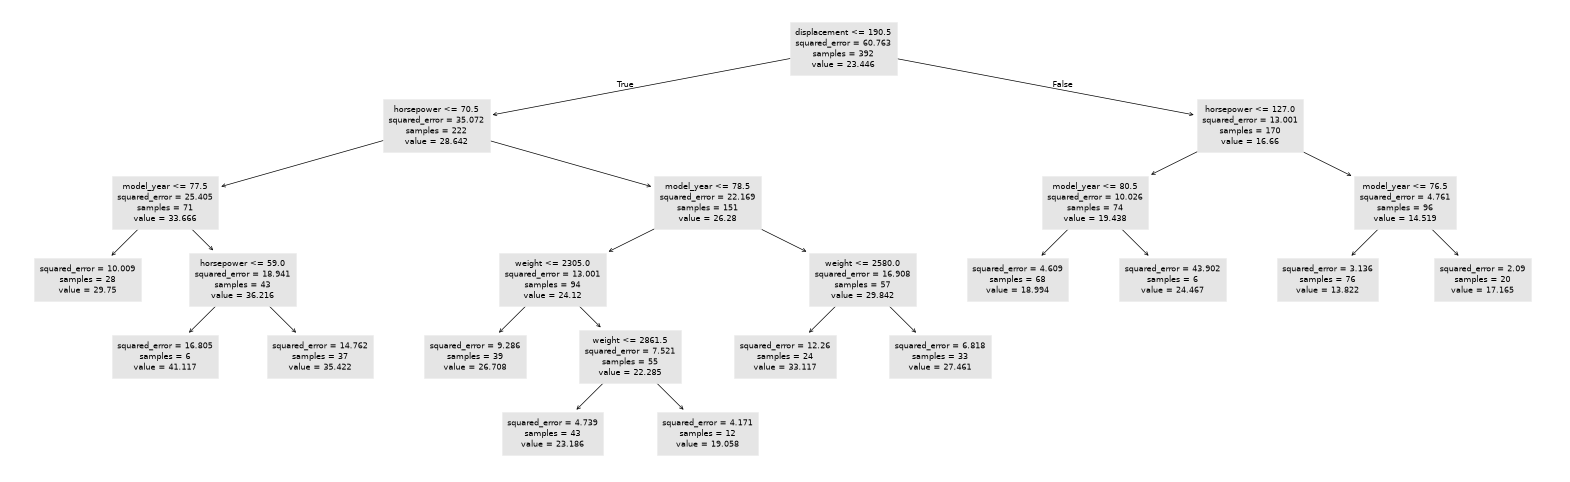

In [9]:
model_1se = DecisionTreeRegressor(random_state=42,
                                  ccp_alpha=summary["alpha_1se"],
                                  **base_params).fit(X, y)

print("Hojas (alpha_1se):", model_1se.get_n_leaves())
print("Profundidad:", model_1se.get_depth())
plt.figure(figsize=(20,6))
ars = plot_tree(model_1se, feature_names=features, fontsize=6)